<a href="https://colab.research.google.com/github/Abel-Kurian/Ai-internship/blob/main/Day6_Deep_Learning_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd # Import pandas to read the CSV
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

zip_path = "/content/archive (2).zip"
extract_path = "extracted_images"
IMG_SIZE = 128 # Define a consistent image size for the CNN

# Class names for the brain tumor dataset based on the CSV labels
class_names = ['Normal', 'Brain Tumor']

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

images = []
labels = []

# Path to the CSV file and the directory containing images
csv_file_path = os.path.join(extract_path, 'Brain Tumor.csv')
image_base_dir = os.path.join(extract_path, 'Brain Tumor', 'Brain Tumor') # Based on !ls output

# Read the CSV file
try:
    df = pd.read_csv(csv_file_path)
except FileNotFoundError:
    print(f"Error: '{csv_file_path}' not found. Please ensure the CSV is correctly extracted.")
    exit() # Exit if CSV is not found

# Iterate through the DataFrame to load images and assign labels
for index, row in df.iterrows():
    # Image names in CSV are like 'Image1', 'Image2', etc. Append '.jpg'
    img_filename = row['Image'] + '.jpg'
    img_path = os.path.join(image_base_dir, img_filename)

    img = cv2.imread(img_path)

    if img is not None:
        # Convert to grayscale
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Resize image to a consistent size
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(row['Class']) # Use the 'Class' column from CSV as label
    else:
        print(f"Warning: Could not load image {img_path}")

print(f"Found {len(images)} images with {len(set(labels))} unique labels.")
print(f"Class names and their mapping: {dict(zip(class_names, range(len(class_names))))}")

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Normalize images (pixel values to 0-1)
images = images / 255.0

# Reshape for CNN input (add channel dimension for grayscale images: (num_samples, IMG_SIZE, IMG_SIZE, 1))
images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Perform train-test split
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

Found 3762 images with 2 unique labels.
Class names and their mapping: {'Normal': 0, 'Brain Tumor': 1}
x_train shape: (3009, 128, 128, 1)
y_train shape: (3009,)
x_test shape: (753, 128, 128, 1)
y_test shape: (753,)


In [34]:
import pandas as pd

print("Contents of Brain Tumor.csv:")
try:
    df_bt = pd.read_csv(os.path.join(extract_path, 'Brain Tumor.csv'))
    print(df_bt.head())
except FileNotFoundError:
    print(f"'Brain Tumor.csv' not found at {os.path.join(extract_path, 'Brain Tumor.csv')}")

print("\nContents of bt_dataset_t3.csv:")
try:
    df_t3 = pd.read_csv(os.path.join(extract_path, 'bt_dataset_t3.csv'))
    print(df_t3.head())
except FileNotFoundError:
    print(f"'bt_dataset_t3.csv' not found at {os.path.join(extract_path, 'bt_dataset_t3.csv')}")

Contents of Brain Tumor.csv:
    Image  Class      Mean     Variance  Standard Deviation   Entropy  \
0  Image1      0  6.535339   619.587845           24.891522  0.109059   
1  Image2      0  8.749969   805.957634           28.389393  0.266538   
2  Image3      1  7.341095  1143.808219           33.820234  0.001467   
3  Image4      1  5.958145   959.711985           30.979219  0.001477   
4  Image5      0  7.315231   729.540579           27.010009  0.146761   

   Skewness   Kurtosis    Contrast    Energy       ASM  Homogeneity  \
0  4.276477  18.900575   98.613971  0.293314  0.086033     0.530941   
1  3.718116  14.464618   63.858816  0.475051  0.225674     0.651352   
2  5.061750  26.479563   81.867206  0.031917  0.001019     0.268275   
3  5.677977  33.428845  151.229741  0.032024  0.001026     0.243851   
4  4.283221  19.079108  174.988756  0.343849  0.118232     0.501140   

   Dissimilarity  Correlation     Coarseness  
0       4.473346     0.981939  7.458341e-155  
1       3.2

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 848ms/step - accuracy: 0.7647 - loss: 0.5199 - val_accuracy: 0.6600 - val_loss: 0.5858
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 847ms/step - accuracy: 0.8026 - loss: 0.4237 - val_accuracy: 0.8114 - val_loss: 0.4164
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 829ms/step - accuracy: 0.8631 - loss: 0.3270 - val_accuracy: 0.8579 - val_loss: 0.3261
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 89s 935ms/step - accuracy: 0.8790 - loss: 0.2997 - val_accuracy: 0.8765 - val_loss: 0.2747
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 79s 831ms/step - accuracy: 0.9053 - loss: 0.2393 - val_accuracy: 0.8765 - val_loss: 0.2987
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 876ms/step - accuracy: 0.9079 - loss: 0.2330 - val_accuracy: 0.9097 - val_loss: 0.2177
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 838ms/step - accuracy: 0.9292 - loss: 0.1896 - val_accuracy: 0.8805 - val_loss: 0.2917
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 844ms/step - accuracy: 0.9355 - loss: 0.1758 - val_accu

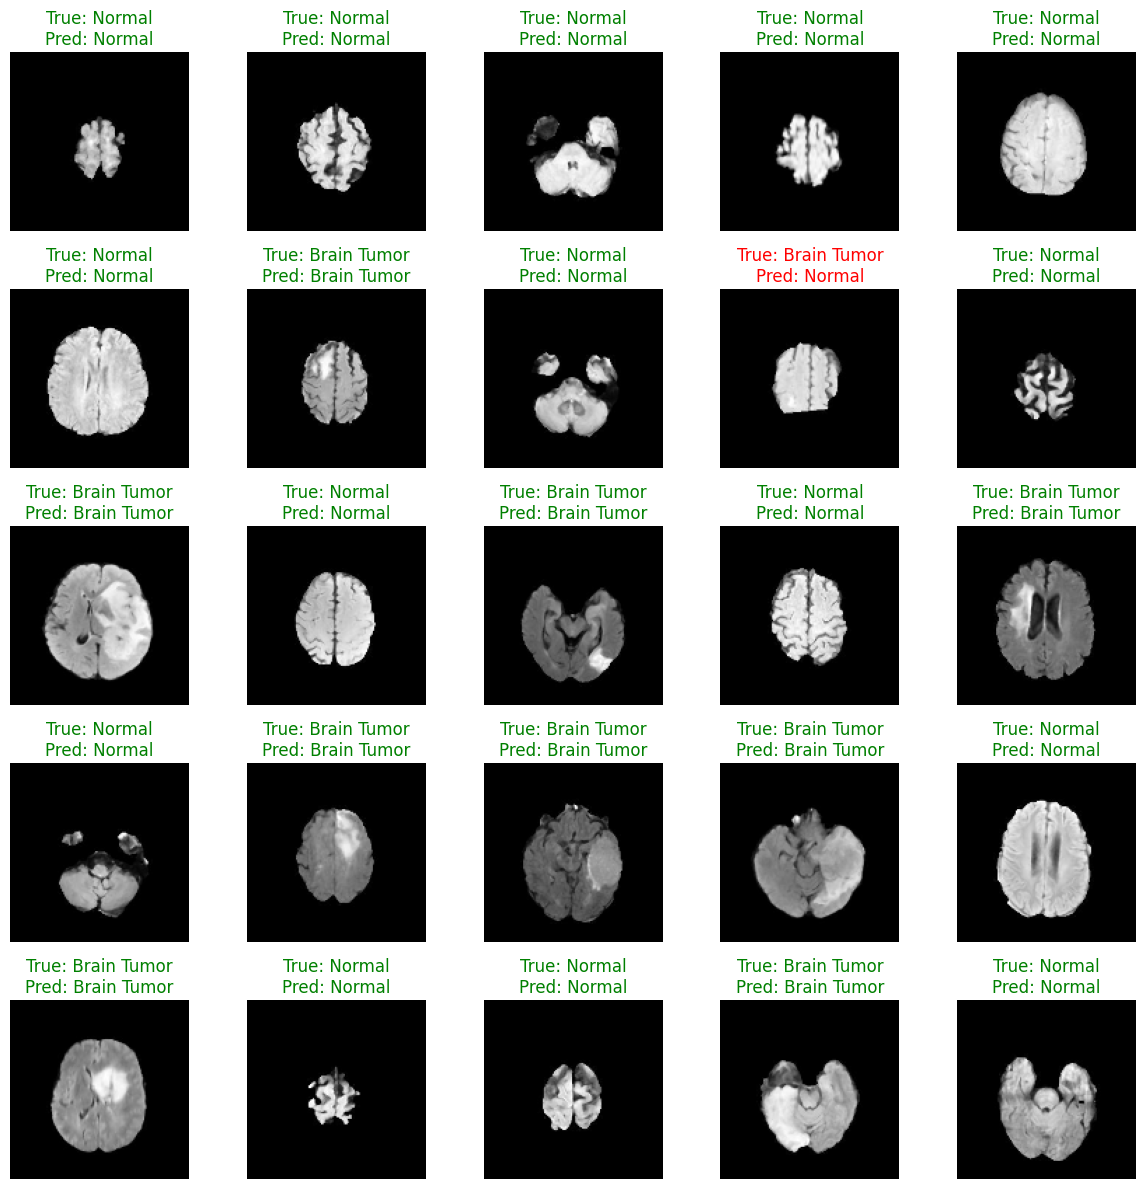

In [37]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# The variables x_train, y_train, x_test, y_test, IMG_SIZE, and class_names
# are expected to be defined in the previous data loading and preprocessing cell.

# Build a CNN model suitable for brain tumor detection with Dropout for regularization
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)), # Input shape adjusted for grayscale brain images
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25), # Added dropout layer

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25), # Added dropout layer

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5), # Added dropout layer before output to prevent overfitting on dense layer
    keras.layers.Dense(len(class_names), activation='softmax') # Output units equal to the number of classes (Normal, Brain Tumor)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with the preprocessed brain tumor data
# Using validation_data to monitor performance on unseen data during training
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test)) # Increased epochs to 10 for better training with dropout

# Evaluate model performance on the test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Predict on test images
predictions = model.predict(x_test)

# Plot some predictions to visualize model performance
plt.figure(figsize=(12, 12)) # Adjusted figure size for better visualization

# Plot up to 25 images (5x5 grid)
num_images_to_plot = min(25, len(x_test))
for i in range(num_images_to_plot):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")

    # Get true and predicted labels
    true_label = class_names[y_test[i]]
    predicted_label_idx = np.argmax(predictions[i])
    predicted_label = class_names[predicted_label_idx]

    # Set title with true and predicted labels
    plt.title(f"True: {true_label}\nPred: {predicted_label}",
              color="green" if true_label == predicted_label else "red")
    plt.axis("off")
plt.tight_layout()
plt.show()